# Crop Disease Forecast — Preprocessing
**Mini Project | DS/AIML-A 2026**

This notebook demonstrates the full data cleaning and preprocessing pipeline step by step.

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
print('Libraries loaded!')

Libraries loaded!


## 2. Load Raw Data

In [2]:
df = pd.read_csv('../dataset/raw_data/climate_data.csv', parse_dates=['date'])
print('Raw data shape:', df.shape)
df.head()

Raw data shape: (1461, 9)


,date,temp_max,temp_min,rainfall_mm,wind_speed,humidity_max,humidity_min,temp_avg,humidity_avg
0,2020-01-01,29.1,22.5,2.3,15.1,98,69,25.80,83.5
1,2020-01-02,29.6,23.3,1.7,12.0,98,66,26.45,82.0
2,2020-01-03,30.5,23.2,1.9,10.8,99,65,26.85,82.0
3,2020-01-04,30.4,22.4,2.0,10.2,100,70,26.40,85.0
4,2020-01-05,30.0,22.9,1.3,12.3,100,69,26.45,84.5


## 3. Check Missing Values

Missing values per column:
date            0
temp_max        0
temp_min        0
rainfall_mm     0
wind_speed      0
humidity_max    0
humidity_min    0
temp_avg        0
humidity_avg    0
dtype: int64


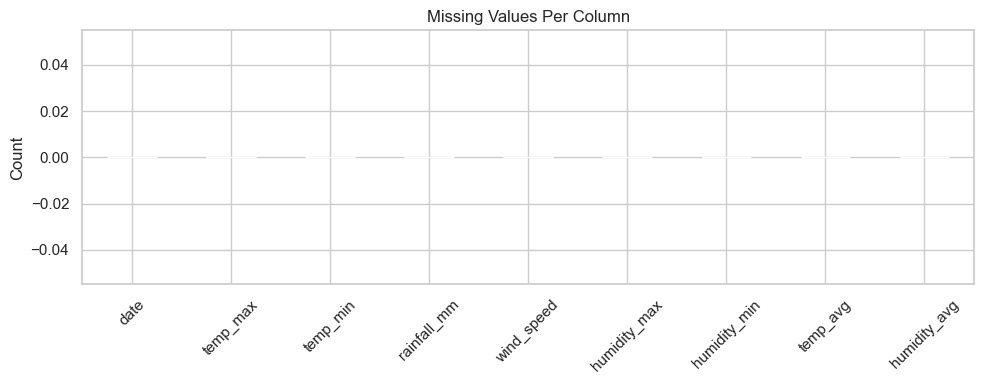

In [3]:
missing = df.isnull().sum()
print('Missing values per column:')
print(missing)

# Visualise missing values
plt.figure(figsize=(10, 4))
missing.plot(kind='bar', color='#e74c3c')
plt.title('Missing Values Per Column')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../outputs/graphs/missing_values.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Handle Missing Values

In [4]:
# Fill missing values with column mean
df.fillna(df.mean(numeric_only=True), inplace=True)
print('Missing values after filling:')
print(df.isnull().sum())

Missing values after filling:
date            0
temp_max        0
temp_min        0
rainfall_mm     0
wind_speed      0
humidity_max    0
humidity_min    0
temp_avg        0
humidity_avg    0
dtype: int64


## 5. Remove Outliers

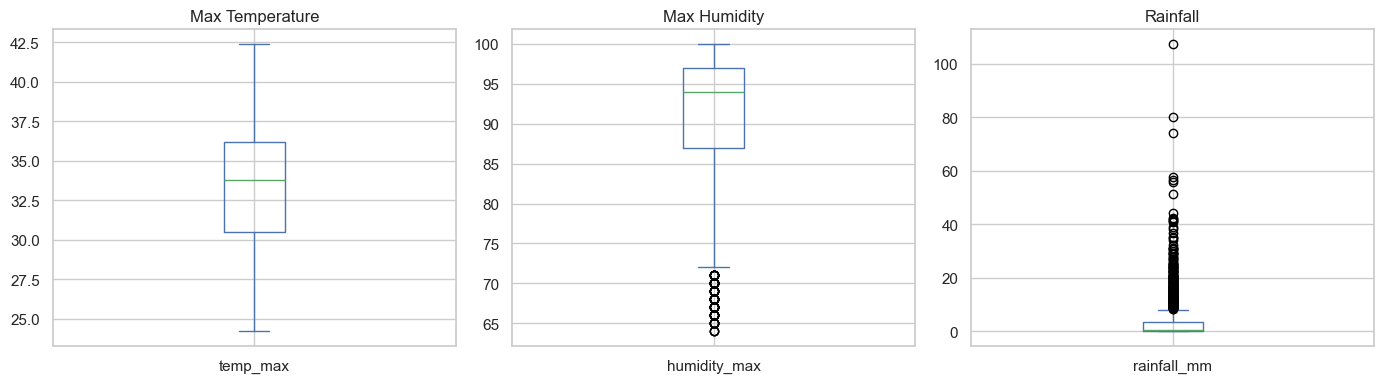

Rows removed: 0
Rows remaining: 1461


In [5]:
# Show boxplots before removing outliers
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

df['temp_max'].plot(kind='box', ax=axes[0], title='Max Temperature')
df['humidity_max'].plot(kind='box', ax=axes[1], title='Max Humidity')
df['rainfall_mm'].plot(kind='box', ax=axes[2], title='Rainfall')

plt.tight_layout()
plt.savefig('../outputs/graphs/boxplots_before.png', dpi=150, bbox_inches='tight')
plt.show()

# Remove temperature outliers
before = len(df)
df = df[(df['temp_max'] >= 10) & (df['temp_max'] <= 50)]
df = df[(df['temp_min'] >= 10) & (df['temp_min'] <= 50)]
print(f'Rows removed: {before - len(df)}')
print(f'Rows remaining: {len(df)}')

## 6. Feature Engineering

In [6]:
# Add new useful columns
df['month']         = df['date'].dt.month
df['year']          = df['date'].dt.year
df['temp_range']    = df['temp_max'] - df['temp_min']
df['high_humidity'] = (df['humidity_avg'] > 80).astype(int)
df['heavy_rain']    = (df['rainfall_mm'] > 10).astype(int)

def get_season(month):
    if month in [6,7,8,9]:    return 'Monsoon'
    elif month in [10,11]:     return 'Post-Monsoon'
    elif month in [12,1,2]:    return 'Winter'
    else:                      return 'Summer'

df['season'] = df['month'].apply(get_season)

print('New columns added!')
df[['date','temp_range','high_humidity','heavy_rain','season']].head(10)

New columns added!


,date,temp_range,high_humidity,heavy_rain,season
0,2020-01-01,6.6,1,0,Winter
1,2020-01-02,6.3,1,0,Winter
2,2020-01-03,7.3,1,0,Winter
3,2020-01-04,8.0,1,0,Winter
4,2020-01-05,7.1,1,0,Winter
5,2020-01-06,6.0,1,0,Winter
6,2020-01-07,6.1,1,0,Winter
7,2020-01-08,7.0,0,0,Winter
8,2020-01-09,9.8,0,0,Winter
9,2020-01-10,10.4,0,0,Winter


## 7. Season Distribution

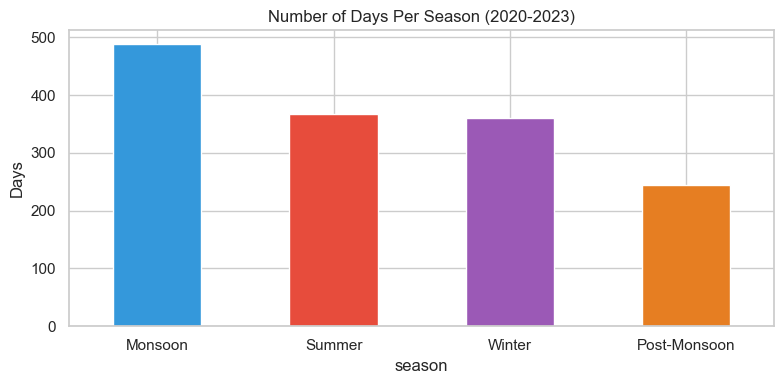

In [7]:
plt.figure(figsize=(8, 4))
season_colors = {'Monsoon':'#3498db','Post-Monsoon':'#e67e22','Winter':'#9b59b6','Summer':'#e74c3c'}
counts = df['season'].value_counts()
counts.plot(kind='bar', color=[season_colors[s] for s in counts.index])
plt.title('Number of Days Per Season (2020-2023)')
plt.ylabel('Days')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../outputs/graphs/season_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Save Cleaned Data

In [8]:
df.to_csv('../dataset/processed_data/climate_cleaned.csv', index=False)
print('Cleaned data saved!')
print('Final shape:', df.shape)
df.head()

Cleaned data saved!
Final shape: (1461, 15)


,date,temp_max,temp_min,rainfall_mm,wind_speed,humidity_max,humidity_min,temp_avg,humidity_avg,month,year,temp_range,high_humidity,heavy_rain,season
0,2020-01-01,29.1,22.5,2.3,15.1,98,69,25.80,83.5,1,2020,6.6,1,0,Winter
1,2020-01-02,29.6,23.3,1.7,12.0,98,66,26.45,82.0,1,2020,6.3,1,0,Winter
2,2020-01-03,30.5,23.2,1.9,10.8,99,65,26.85,82.0,1,2020,7.3,1,0,Winter
3,2020-01-04,30.4,22.4,2.0,10.2,100,70,26.40,85.0,1,2020,8.0,1,0,Winter
4,2020-01-05,30.0,22.9,1.3,12.3,100,69,26.45,84.5,1,2020,7.1,1,0,Winter
